#### Importing Libraries and Full dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

In [2]:
BASE_DIR = "../../Dataset/"

In [3]:
full_data = pd.read_parquet(os.path.join(BASE_DIR, "dataset.parquet"))
full_data.columns = [ col.lower() for col in full_data.columns ]
full_data.head()

,protocol,flow duration,total fwd packets,total backward packets,fwd packets length total,bwd packets length total,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,fwd seg size min,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min,label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [4]:
from pprint import pprint

pprint(full_data.columns)
pprint(len(full_data.columns))

Index(['protocol', 'flow duration', 'total fwd packets',
       'total backward packets', 'fwd packets length total',
       'bwd packets length total', 'fwd packet length max',
       'fwd packet length min', 'fwd packet length mean',
       'fwd packet length std', 'bwd packet length max',
       'bwd packet length min', 'bwd packet length mean',
       'bwd packet length std', 'flow bytes/s', 'flow packets/s',
       'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min',
       'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max',
       'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std',
       'bwd iat max', 'bwd iat min', 'fwd psh flags', 'bwd psh flags',
       'fwd urg flags', 'bwd urg flags', 'fwd header length',
       'bwd header length', 'fwd packets/s', 'bwd packets/s',
       'packet length min', 'packet length max', 'packet length mean',
       'packet length std', 'packet length variance', 'fin flag count',
       'syn flag count', 'rst fla

In [5]:
full_data["label"] = full_data["label"].apply(lambda x: "Benign" if x == "Benign" else "Malicious")
full_data

,protocol,flow duration,total fwd packets,total backward packets,fwd packets length total,bwd packets length total,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,fwd seg size min,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min,label
0,6,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.142860,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2313805,6,49,3,0,76,0,45,0,25.333334,23.028967,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2313806,6,1286687,41,42,2664,6954,456,0,64.975609,109.864571,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2313807,6,181,3,1,18,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2313808,6,217,2,1,31,6,31,0,15.500000,21.920311,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [6]:
from sklearn.tree import DecisionTreeClassifier 

feeature_imp_tree = DecisionTreeClassifier(random_state=42)
feeature_imp_tree.fit(full_data.drop(columns=["label"]), full_data["label"])

DecisionTreeClassifier(random_state=42)

In [7]:
feature_importances = pd.DataFrame({
    "feature": full_data.drop(columns=["label"]).columns,
    "importance": feeature_imp_tree.feature_importances_
})

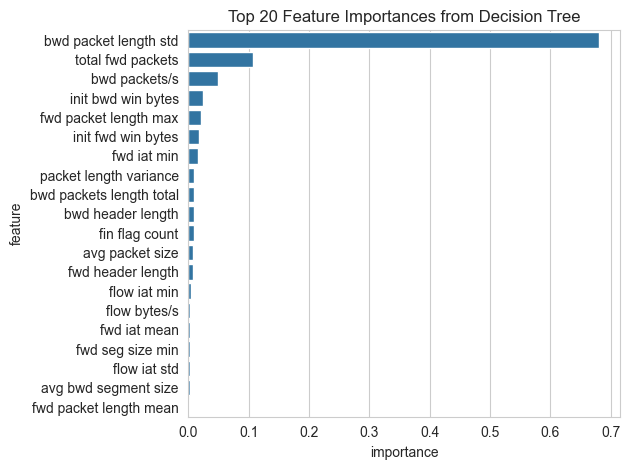

In [8]:
sns.barplot(data=feature_importances.sort_values("importance", ascending=False).head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances from Decision Tree")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_feature_imp = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_feature_imp.fit(full_data.drop(columns=["label"]), full_data["label"])

RandomForestClassifier(n_jobs=-1, random_state=42)

In [10]:
feature_importances = pd.DataFrame({
    "feature": full_data.drop(columns=["label"]).columns,
    "importance": rf_feature_imp.feature_importances_
})

Text(0.5, 1.0, 'Top 20 Feature Importances from Random Forest')

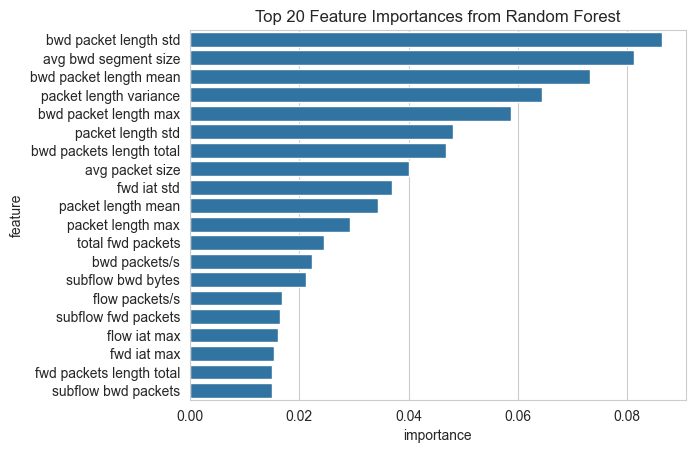

In [11]:
sns.barplot(data=feature_importances.sort_values("importance", ascending=False).head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances from Random Forest")

In [12]:
top_20_features_rf = feature_importances.sort_values("importance", ascending=False).head(20)["feature"].tolist()
print("Top 20 features:", top_20_features_rf)

Top 20 features: ['bwd packet length std', 'avg bwd segment size', 'bwd packet length mean', 'packet length variance', 'bwd packet length max', 'packet length std', 'bwd packets length total', 'avg packet size', 'fwd iat std', 'packet length mean', 'packet length max', 'total fwd packets', 'bwd packets/s', 'subflow bwd bytes', 'flow packets/s', 'subflow fwd packets', 'flow iat max', 'fwd iat max', 'fwd packets length total', 'subflow bwd packets']


In [13]:
X = full_data.drop(columns=["label"])
y = full_data["label"]

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = X 
features_scaled = StandardScaler().fit_transform(features)
pca = PCA(n_components=20, random_state=42)

In [15]:
pca_features = pca.fit_transform(features_scaled)
pca_df = pd.DataFrame(data=pca_features, columns=[f"PC{i+1}" for i in range(pca_features.shape[1])])
pca_df["label"] = y.values

In [16]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,label
0,-2.228387,-0.042500,0.245913,0.348388,-3.439635,-2.963631,-0.924006,1.187485,0.658898,1.386057,...,-0.064000,-2.279435,-0.032882,-0.073528,0.073167,0.351681,-0.548681,-0.332836,-0.486430,Benign
1,-2.838485,-0.058536,0.465545,0.717698,-7.968682,-8.422288,-3.421595,6.525666,4.608204,7.613869,...,-0.190916,-4.518487,0.804545,-2.669562,1.076890,0.419246,-0.757018,-0.421295,-0.654297,Benign
2,-2.296303,-0.044366,0.270822,0.388723,-3.941981,-3.571001,-1.203006,1.781152,1.097502,2.077916,...,-0.078073,-2.528674,0.060115,-0.361417,0.184142,0.359752,-0.573046,-0.343147,-0.505721,Benign
3,-2.838612,-0.058620,0.466050,0.716999,-7.967801,-8.423141,-3.423085,6.526202,4.607996,7.613749,...,-0.190887,-4.518942,0.804495,-2.669002,1.076340,0.419810,-0.758235,-0.421778,-0.654936,Benign
4,-1.497870,0.113330,-0.674101,0.722562,-0.976281,0.519302,1.068048,-0.837637,0.117171,0.082671,...,-0.030788,0.145442,0.246469,-0.627440,-0.261569,-0.519336,-0.117125,-0.022265,-0.030549,Benign


In [17]:
pca_features = pca_df.drop(columns=["label"])
corr = pca_features.corr()

Text(0.5, 1.0, 'Correlation Heatmap of PCA Components')

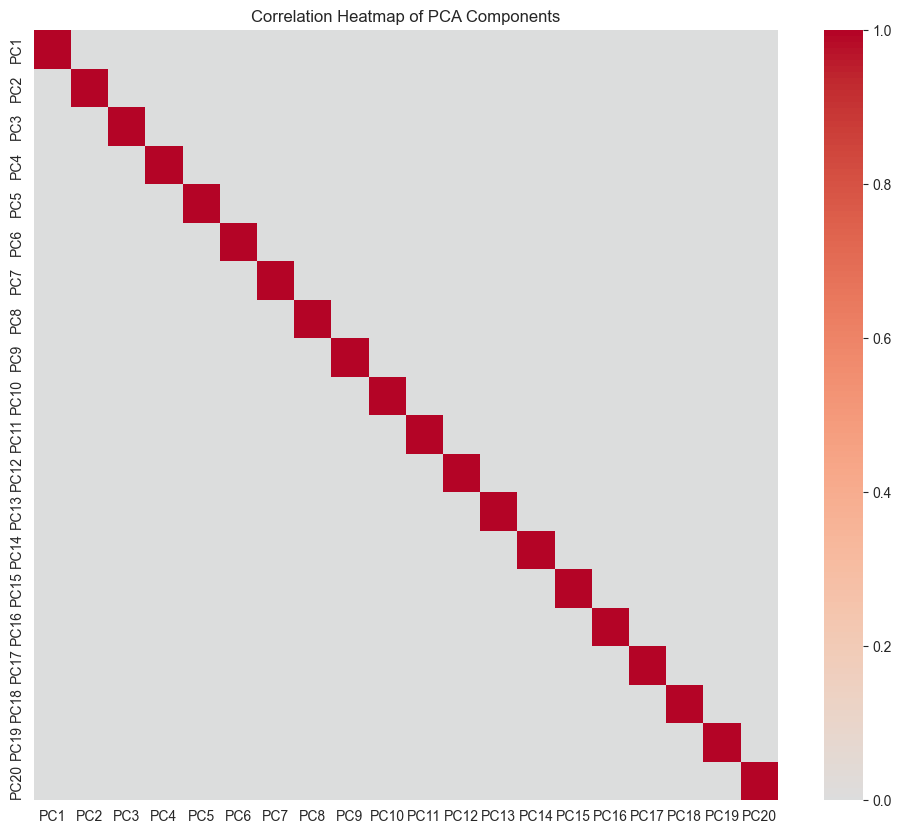

In [18]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of PCA Components")

In [19]:
pca_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
pca_rf.fit(pca_features, pca_df["label"])

RandomForestClassifier(n_jobs=-1, random_state=42)

In [20]:
pca_feature_imp = pd.DataFrame({
    "feature": pca_features.columns,
    "importance": pca_rf.feature_importances_
})

<Axes: xlabel='importance', ylabel='feature'>

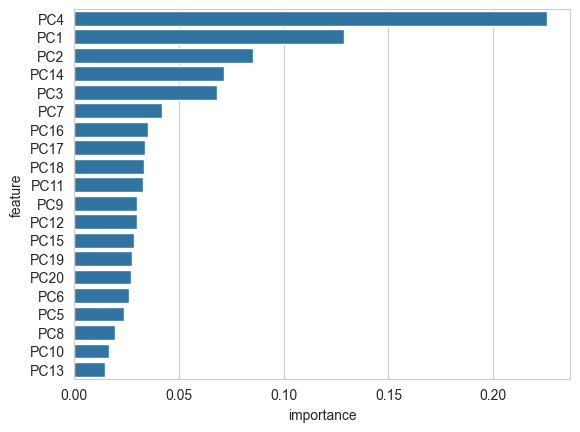

In [21]:
sns.barplot(data=pca_feature_imp.sort_values("importance", ascending=False), x="importance", y="feature")

In [22]:
new_pca = PCA(n_components=10, random_state=42)
pca_features_10 = new_pca.fit_transform(features_scaled)

In [23]:
pca_10_df = pd.DataFrame(data=pca_features_10, columns=[f"PC{i+1}" for i in range(pca_features_10.shape[1])])
pca_10_df["label"] = y.values

##### Saving all data and thein processed versions

In [24]:
rf_feature_imp_20 = full_data[top_20_features_rf + ["label"]]
rf_feature_imp_20.sample(5)

,bwd packet length std,avg bwd segment size,bwd packet length mean,packet length variance,bwd packet length max,packet length std,bwd packets length total,avg packet size,fwd iat std,packet length mean,...,total fwd packets,bwd packets/s,subflow bwd bytes,flow packets/s,subflow fwd packets,flow iat max,fwd iat max,fwd packets length total,subflow bwd packets,label
1291431,0.000000,0.000000,0.000000,0.000000e+00,0,0.000000,0,9.000000,0.0,6.000000,...,2,0.000000,0,1.762259,2,1134907,1134907,12,0,Benign
1954549,0.000000,6.000000,6.000000,4.800000e+00,6,2.190890,12,4.500000,0.0,3.600000,...,2,29850.746094,12,59701.492540,2,49,13,4,2,Benign
2109422,926.710876,1598.898682,1598.898682,1.122626e+06,4344,1059.540649,126313,1029.008057,3512554.0,1020.776001,...,45,1.198963,126313,1.881916,45,10000000,10200000,1284,79,Benign
1410545,2119.480225,1656.428589,1656.428589,2.937576e+06,5792,1713.935791,11595,998.583313,42700000.0,921.769226,...,5,0.081890,11595,0.140383,5,85300000,85300000,382,7,Malicious
2164179,0.000000,122.000000,122.000000,1.045333e+03,122,32.331615,122,127.000000,0.0,84.666664,...,1,31.720856,122,63.441713,1,31525,0,66,1,Benign


In [25]:
pca_10_df.to_parquet(os.path.join(BASE_DIR, "pca_10_df.parquet"), index=False)
rf_feature_imp_20.to_parquet(os.path.join(BASE_DIR, "rf_top_20.parquet"), index=False)